# Data Exploration and Visualisation 



## Hypotheses

1. Students who studied longer hours performed better in their exams.
2. The type of school has no effect on exam outcome 

In [86]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

In [87]:
df1= pd.read_csv('student_clean.csv')
df1

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Grade
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Medium,Public,Positive,3,No,High School,Near,Male,67,B
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,B
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,A
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71,A
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,High,Public,Neutral,4,No,College,Near,Female,70,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6372,25,69,High,Medium,No,7,76,Medium,Yes,1,...,Medium,Public,Positive,2,No,High School,Near,Female,68,B
6373,23,76,High,Medium,No,8,81,Medium,Yes,3,...,High,Public,Positive,2,No,High School,Near,Female,69,B
6374,20,90,Medium,Low,Yes,6,65,Low,Yes,3,...,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68,B
6375,10,86,High,High,Yes,6,91,High,Yes,2,...,Medium,Private,Positive,3,No,High School,Far,Female,68,B


In [88]:
df1.head(5)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Grade
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Medium,Public,Positive,3,No,High School,Near,Male,67,B
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,B
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,A
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71,A
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,High,Public,Neutral,4,No,College,Near,Female,70,A


In [89]:
df1.insert(0,"Student_ID",range(1,len(df1)+1))

#error shown as it thinks a duplicate is being created. Only accepts unique features. - ignore 

In [90]:
df1

,Student_ID,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Grade
0,1,23,84,Low,High,No,7,73,Low,Yes,...,Medium,Public,Positive,3,No,High School,Near,Male,67,B
1,2,19,64,Low,Medium,No,8,59,Low,Yes,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,B
2,3,24,98,Medium,Medium,Yes,7,91,Medium,Yes,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,A
3,4,29,89,Low,Medium,Yes,8,98,Medium,Yes,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71,A
4,5,19,92,Medium,Medium,Yes,6,65,Medium,Yes,...,High,Public,Neutral,4,No,College,Near,Female,70,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6372,6373,25,69,High,Medium,No,7,76,Medium,Yes,...,Medium,Public,Positive,2,No,High School,Near,Female,68,B
6373,6374,23,76,High,Medium,No,8,81,Medium,Yes,...,High,Public,Positive,2,No,High School,Near,Female,69,B
6374,6375,20,90,Medium,Low,Yes,6,65,Low,Yes,...,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68,B
6375,6376,10,86,High,High,Yes,6,91,High,Yes,...,Medium,Private,Positive,3,No,High School,Far,Female,68,B


In [91]:
df1=df1.reset_index(drop=True)

In [92]:
df1

,Student_ID,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Grade
0,1,23,84,Low,High,No,7,73,Low,Yes,...,Medium,Public,Positive,3,No,High School,Near,Male,67,B
1,2,19,64,Low,Medium,No,8,59,Low,Yes,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,B
2,3,24,98,Medium,Medium,Yes,7,91,Medium,Yes,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,A
3,4,29,89,Low,Medium,Yes,8,98,Medium,Yes,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71,A
4,5,19,92,Medium,Medium,Yes,6,65,Medium,Yes,...,High,Public,Neutral,4,No,College,Near,Female,70,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6372,6373,25,69,High,Medium,No,7,76,Medium,Yes,...,Medium,Public,Positive,2,No,High School,Near,Female,68,B
6373,6374,23,76,High,Medium,No,8,81,Medium,Yes,...,High,Public,Positive,2,No,High School,Near,Female,69,B
6374,6375,20,90,Medium,Low,Yes,6,65,Low,Yes,...,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68,B
6375,6376,10,86,High,High,Yes,6,91,High,Yes,...,Medium,Private,Positive,3,No,High School,Far,Female,68,B


#### Data Analysis 


In [255]:
# Top 6 highest grades using df.nlargest, will use .loc to find common relationship between all three 
#


df1["Exam_Score"].nlargest(6)


Student_ID
94      100
2341     99
3455     99
4052     98
6131     98
6177     98
Name: Exam_Score, dtype: int64

In [257]:
df1.query('Exam_Score >= 97')
#no learning disabilities reported
#4/6 public school
# all studied 14 or more hours 
#1/6 had low access to resources, with 1/6 having 0 tutoring sessions (improvment from 91-> 98)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Grade
Student_ID,,,,,,,,,,,,,,,,,,,,,
94,18,89,High,Medium,Yes,4,73,Medium,Yes,3,...,Medium,Private,Positive,2,No,College,Near,Female,100,A
516,15,83,Medium,Medium,No,7,97,Medium,Yes,2,...,High,Private,Neutral,2,No,High School,Near,Female,97,A
886,21,74,High,Medium,No,6,94,Medium,Yes,1,...,High,Public,Positive,1,No,High School,Near,Male,97,A
2341,23,83,High,High,Yes,4,89,Low,Yes,1,...,Medium,Public,Negative,3,No,High School,Far,Male,99,A
3455,14,90,High,High,Yes,8,86,Medium,Yes,4,...,Medium,Private,Negative,2,No,High School,Near,Female,99,A
4052,28,90,Low,Medium,Yes,9,91,Medium,Yes,0,...,Medium,Public,Positive,2,No,College,Moderate,Female,98,A
5764,25,99,Medium,Medium,Yes,7,77,Medium,Yes,0,...,High,Public,Neutral,3,No,High School,Near,Male,97,A
6131,28,96,High,Low,Yes,4,98,High,Yes,1,...,High,Public,Positive,3,No,High School,Near,Male,98,A
6177,16,83,Low,Medium,Yes,8,92,Low,Yes,2,...,High,Public,Positive,4,No,Postgraduate,Near,Female,98,A


In [260]:

df1["Exam_Score"].nsmallest(6)

Student_ID
1058    55
5316    56
2782    57
3420    57
5524    57
5705    57
Name: Exam_Score, dtype: int64

In [259]:
df1.query("Exam_Score <= 57")
# 5/6 low access to resources 
#2/6 pupils attended private
# 1/6 studied 14 hours. 5/6 9 hours or less 
#1/6 SEN

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Grade
Student_ID,,,,,,,,,,,,,,,,,,,,,
1058,3,62,Medium,Low,No,6,67,Medium,Yes,1,...,Medium,Public,Negative,3,No,High School,Near,Male,55,C
2782,7,66,High,Low,Yes,8,68,High,Yes,0,...,Medium,Public,Negative,2,Yes,College,Moderate,Male,57,C
3420,14,67,Low,Low,Yes,7,66,Low,Yes,0,...,Medium,Public,Neutral,4,No,High School,Far,Female,57,C
5316,5,65,Low,High,No,7,71,Medium,Yes,0,...,Medium,Private,Negative,2,No,College,Far,Male,56,C
5524,9,64,Medium,Low,Yes,10,68,Low,Yes,0,...,Medium,Private,Negative,3,No,High School,Near,Male,57,C
5705,3,60,Medium,Low,Yes,6,78,Low,Yes,1,...,Medium,Public,Positive,1,No,Postgraduate,Near,Female,57,C


In [113]:
df1=df1.set_index("Student_ID")

In [114]:
df1

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Grade
Student_ID,,,,,,,,,,,,,,,,,,,,,
1,23,84,Low,High,No,7,73,Low,Yes,0,...,Medium,Public,Positive,3,No,High School,Near,Male,67,B
2,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,B
3,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,A
4,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71,A
5,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,High,Public,Neutral,4,No,College,Near,Female,70,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6373,25,69,High,Medium,No,7,76,Medium,Yes,1,...,Medium,Public,Positive,2,No,High School,Near,Female,68,B
6374,23,76,High,Medium,No,8,81,Medium,Yes,3,...,High,Public,Positive,2,No,High School,Near,Female,69,B
6375,20,90,Medium,Low,Yes,6,65,Low,Yes,3,...,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68,B


In [142]:
df1.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6377.000000,6377.000000,6377.000000,6377.000000,6377.000000,6377.000000,6377.000000
mean,19.976008,80.018034,7.035126,75.063353,1.494747,2.972714,67.246825
std,5.985283,11.549434,1.468091,14.399766,1.233300,1.029006,3.891637
min,1.000000,60.000000,4.000000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.000000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.000000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.000000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.000000,100.000000,8.000000,6.000000,100.000000


<Axes: ylabel='Frequency'>

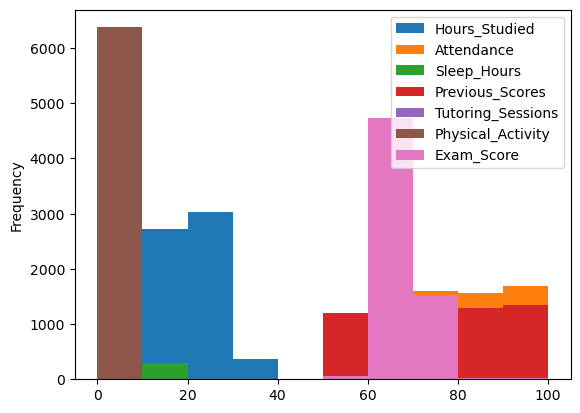

In [193]:
df1.plot.hist(bins= 10)

In [236]:
high_scores=df1.loc[[94,2341,3455]]


In [237]:
low_scores=df1.loc[[1058,5316,2782]]

#### Data Visualisation


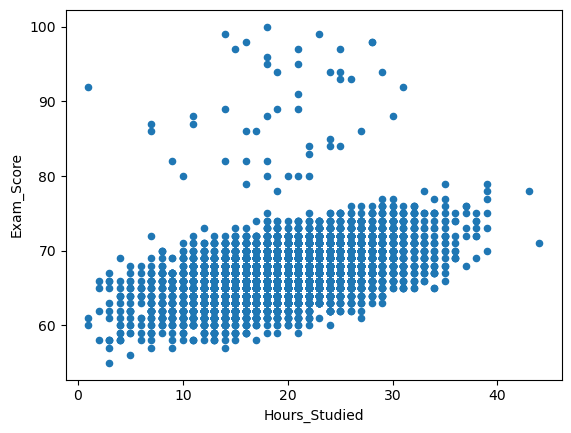

In [238]:
df1.plot.scatter(x='Hours_Studied',
                 y='Exam_Score')

plt.show()

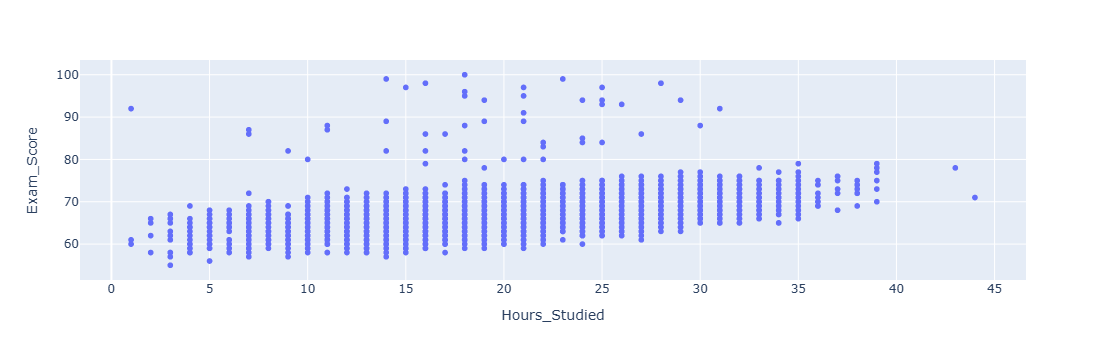

In [240]:
#plotly chart below allows us to hover over the scatter plots to reveal information- This is for all pupil entries 
df=px.data.tips()
fig=px.scatter(data_frame=df1,x='Hours_Studied',y='Exam_Score')
fig.show()

Using information from three of the highest scoring students, some information on what may have contributed
to their score are displayed below. 

outliers**

<Axes: xlabel='Student_ID'>

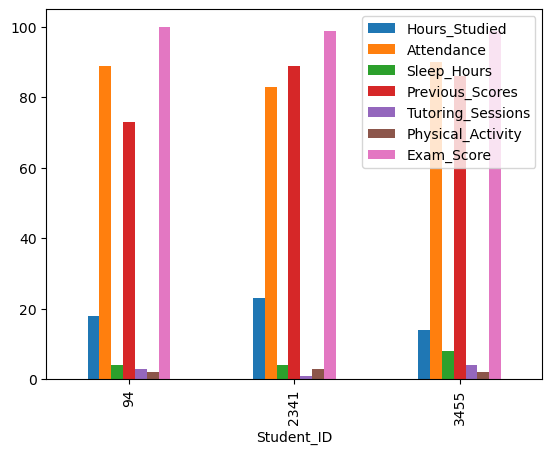

In [301]:
high_scores.plot(kind = 'bar')



<Axes: xlabel='Hours_Studied', ylabel='Exam_Score'>

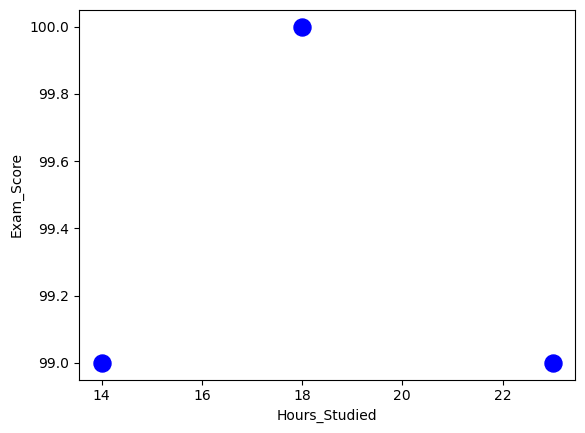

In [302]:
high_scores.plot.scatter(x = 'Hours_Studied', y = 'Exam_Score',s=150, c= 'blue')

<Axes: >

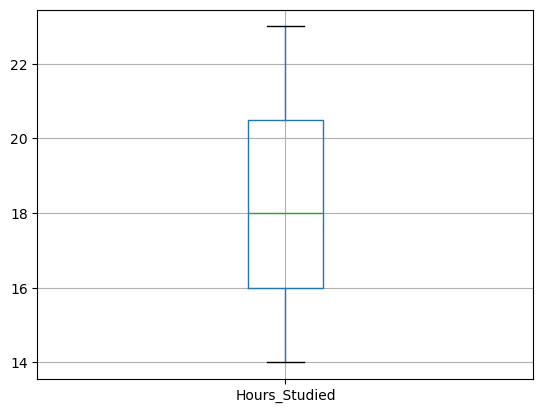

In [300]:
high_scores.boxplot(['Hours_Studied'])


## Hypothesis 1 - Students who studied longer hours performed better in their exams. 

- Comparing the test scores against the hours studied for top and lowest 3 exam scores

In [261]:
high_low=df1.loc[[94,2341,3455,4052,6131,6177,
                  1058,5316,2782,3420,5524,5705]]

In [270]:
high_low


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Grade
Student_ID,,,,,,,,,,,,,,,,,,,,,
94,18,89,High,Medium,Yes,4,73,Medium,Yes,3,...,Medium,Private,Positive,2,No,College,Near,Female,100,A
2341,23,83,High,High,Yes,4,89,Low,Yes,1,...,Medium,Public,Negative,3,No,High School,Far,Male,99,A
3455,14,90,High,High,Yes,8,86,Medium,Yes,4,...,Medium,Private,Negative,2,No,High School,Near,Female,99,A
4052,28,90,Low,Medium,Yes,9,91,Medium,Yes,0,...,Medium,Public,Positive,2,No,College,Moderate,Female,98,A
6131,28,96,High,Low,Yes,4,98,High,Yes,1,...,High,Public,Positive,3,No,High School,Near,Male,98,A
6177,16,83,Low,Medium,Yes,8,92,Low,Yes,2,...,High,Public,Positive,4,No,Postgraduate,Near,Female,98,A
1058,3,62,Medium,Low,No,6,67,Medium,Yes,1,...,Medium,Public,Negative,3,No,High School,Near,Male,55,C
5316,5,65,Low,High,No,7,71,Medium,Yes,0,...,Medium,Private,Negative,2,No,College,Far,Male,56,C
2782,7,66,High,Low,Yes,8,68,High,Yes,0,...,Medium,Public,Negative,2,Yes,College,Moderate,Male,57,C


<Axes: title={'center': 'Hours studied vs Exam score'}, xlabel='Student_ID'>

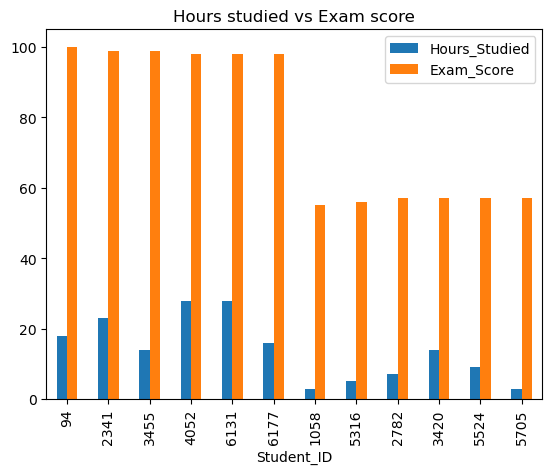

In [295]:
#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html

high_low[['Hours_Studied','Exam_Score']].plot(kind= 'bar', title= 'Hours studied vs Exam score')

<Axes: title={'center': 'Hours studied vs Exam Score'}, xlabel='Hours_Studied', ylabel='Exam_Score'>

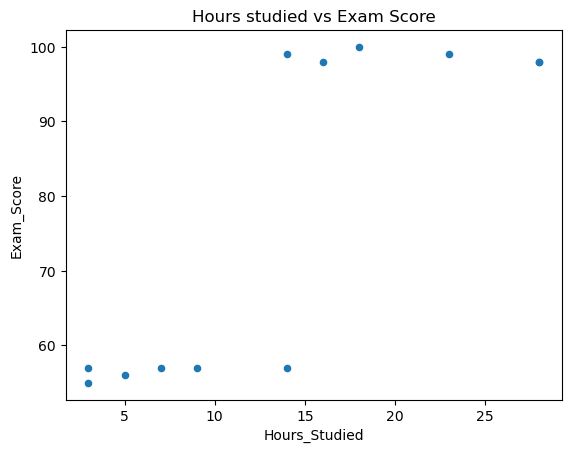

In [304]:
high_low.plot.scatter(x = 'Hours_Studied', y = 'Exam_Score', title= 'Hours studied vs Exam Score')

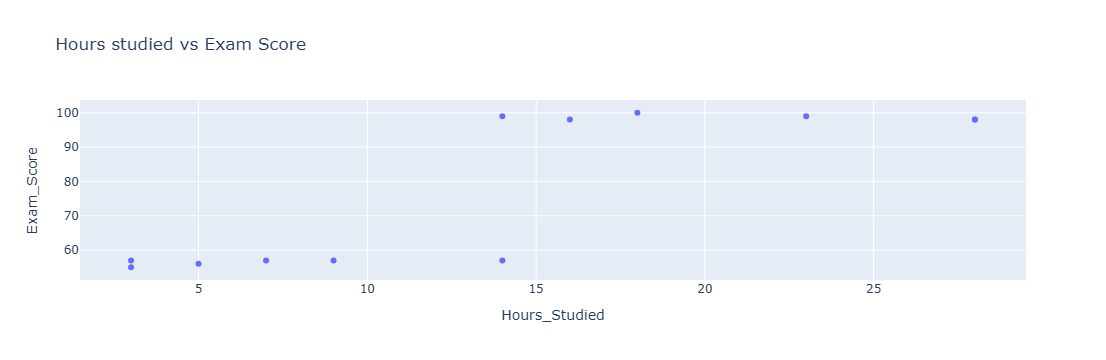

In [268]:
high_low_1=px.data.tips()
fig=px.scatter(data_frame=high_low,
               x='Hours_Studied',
               y='Exam_Score',
               title= 'Hours studied vs Exam Score')
fig.show()

The above scatter graph provides better insight to each pupil, score and study hours. You can hover over each point to reveal information. 
Students who studied longer than 14 hours scored higher on exams. With the exception of student '3420'. I will investigate possible factors below.

In [272]:
high_low.loc[[3420,3455]]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Grade
Student_ID,,,,,,,,,,,,,,,,,,,,,
3420,14,67,Low,Low,Yes,7,66,Low,Yes,0,...,Medium,Public,Neutral,4,No,High School,Far,Female,57,C
3455,14,90,High,High,Yes,8,86,Medium,Yes,4,...,Medium,Private,Negative,2,No,High School,Near,Female,99,A


Although student 3420 and 3455 had the same hours of study, student 3455 had higher access to resources, motivation level, higher attendance and 4 tutoring sessions compared to student 3420 who had no tutoring sessions and lower access to resources and motivation. 

## Hypothesis 2- Type of School has no effect on exam outcome 
- Using graphs to evaluate whether the type of school (public or private) has any relevance to exam score 

In [307]:
high_low

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Grade
Student_ID,,,,,,,,,,,,,,,,,,,,,
94,18,89,High,Medium,Yes,4,73,Medium,Yes,3,...,Medium,Private,Positive,2,No,College,Near,Female,100,A
2341,23,83,High,High,Yes,4,89,Low,Yes,1,...,Medium,Public,Negative,3,No,High School,Far,Male,99,A
3455,14,90,High,High,Yes,8,86,Medium,Yes,4,...,Medium,Private,Negative,2,No,High School,Near,Female,99,A
4052,28,90,Low,Medium,Yes,9,91,Medium,Yes,0,...,Medium,Public,Positive,2,No,College,Moderate,Female,98,A
6131,28,96,High,Low,Yes,4,98,High,Yes,1,...,High,Public,Positive,3,No,High School,Near,Male,98,A
6177,16,83,Low,Medium,Yes,8,92,Low,Yes,2,...,High,Public,Positive,4,No,Postgraduate,Near,Female,98,A
1058,3,62,Medium,Low,No,6,67,Medium,Yes,1,...,Medium,Public,Negative,3,No,High School,Near,Male,55,C
5316,5,65,Low,High,No,7,71,Medium,Yes,0,...,Medium,Private,Negative,2,No,College,Far,Male,56,C
2782,7,66,High,Low,Yes,8,68,High,Yes,0,...,Medium,Public,Negative,2,Yes,College,Moderate,Male,57,C


In [321]:
high_low.value_counts('School_Type')

School_Type
Public     8
Private    4
Name: count, dtype: int64

In [328]:
high_low.groupby('School_Type')

In [336]:
st = high_low.groupby('School_Type')['Exam_Score']



In [347]:
st.mean()

School_Type
Private    78.000
Public     77.375
Name: Exam_Score, dtype: float64

<Axes: title={'center': 'Exam_Score'}, xlabel='School_Type'>

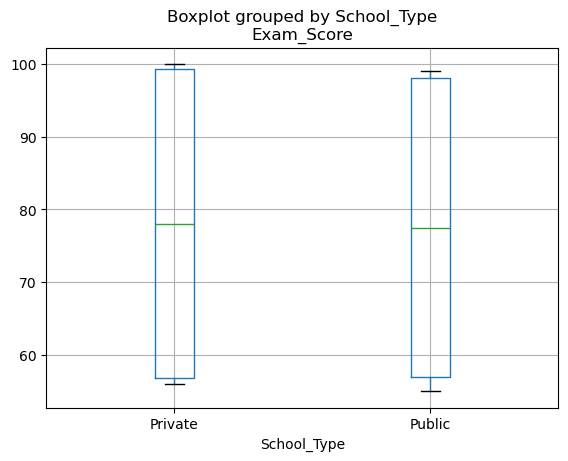

In [359]:
high_low.boxplot(column='Exam_Score',
                 by='School_Type')

In [371]:
high_low.groupby('School_Type')['Exam_Score'].describe()

,count,mean,std,min,25%,50%,75%,max
School_Type,,,,,,,,
Private,4.0,78.000,24.832774,56.0,56.75,78.0,99.25,100.0
Public,8.0,77.375,22.328313,55.0,57.00,77.5,98.00,99.0


Although a private school pupil scored higher overall, the median for both school types are similar and therefore no clear advantage shown. 